# Notebook 2: Exploratory Data Analysis (EDA)
## EEEM073 – AI and Sustainability
### Project: Predicting Burned Area of Forest Fires Using Machine Learning

**Prerequisite:** Run Notebook 1 first — this notebook loads data from the `outputs/` folder.

---
This notebook covers:
1. Load cleaned data
2. Descriptive statistics
3. Target variable analysis
4. Feature distributions (histograms + boxplots)
5. Correlation analysis
6. Feature vs target relationships
7. Temporal analysis (monthly and daily patterns)
8. Spatial analysis (fire location map)
9. Key findings summary


## 1. Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Set a consistent plot style throughout the notebook
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11
})

os.makedirs('outputs', exist_ok=True)

# Load the full cleaned dataframe saved from Notebook 1
df = pd.read_csv('outputs/df_cleaned.csv')

# Also reload the raw CSV to recover the original 'month' and 'day' text columns
# (needed for temporal analysis — cyclic encoding removed them)
df_raw = pd.read_csv('forestfires.csv')

print(f"Cleaned dataset loaded: {df.shape}")
print(f"Raw dataset loaded:     {df_raw.shape}")
df.head(3)

Cleaned dataset loaded: (517, 20)
Raw dataset loaded:     (517, 13)


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_sin,month_cos,day_sin,day_cos,area_log,temp_RH_ratio,fire_spread_potential,FWI_total,drought_wind
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,1.000000,6.123234e-17,-0.433884,-0.900969,0.0,0.157692,34.17,206.7,631.81
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,-0.866025,5.000000e-01,0.781831,0.623490,0.0,0.529412,6.03,795.1,602.19
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,-0.866025,5.000000e-01,-0.974928,-0.222521,0.0,0.429412,8.71,821.2,892.97


## 2. Descriptive Statistics

A summary of central tendency, spread, and range for all numerical features.

In [2]:
# Full descriptive statistics for all columns
desc = df.describe().T
desc['skewness'] = df.skew()  # Add skewness column — important for understanding distributions

print("=== Descriptive Statistics ===")
desc.round(3)

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,skewness
X,517.0,4.669,2.314,1.000,3.000,4.000,7.000,9.000,0.036
Y,517.0,4.300,1.230,2.000,4.000,4.000,5.000,9.000,0.417
FFMC,517.0,91.057,3.103,82.100,90.200,91.600,92.900,96.200,-1.241
DMC,517.0,110.872,64.046,1.100,68.600,108.300,142.400,291.300,0.547
DC,517.0,547.940,248.066,7.900,437.700,664.200,713.900,860.600,-1.100
ISI,517.0,8.959,4.112,0.000,6.500,8.400,10.800,23.700,0.673
temp,517.0,18.889,5.807,2.200,15.500,19.300,22.800,33.300,-0.331
RH,517.0,44.288,16.317,15.000,33.000,42.000,53.000,100.000,0.863
wind,517.0,4.018,1.792,0.400,2.700,4.000,4.900,9.400,0.571
rain,517.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [3]:
# Highlight highly skewed features (|skew| > 1)
high_skew = desc[abs(desc['skewness']) > 1]['skewness'].sort_values(ascending=False)
print("Features with high skewness (|skew| > 1):")
print(high_skew)
print("\nNote: These features may benefit from log transformation in some models.")

Features with high skewness (|skew| > 1):
area                     12.846934
month_sin                 1.476985
fire_spread_potential     1.409856
area_log                  1.217838
FWI_total                -1.005450
DC                       -1.100445
FFMC                     -1.240787
Name: skewness, dtype: float64

Note: These features may benefit from log transformation in some models.


## 3. Target Variable Analysis

Understanding the distribution of the thing we are trying to predict — burned area.

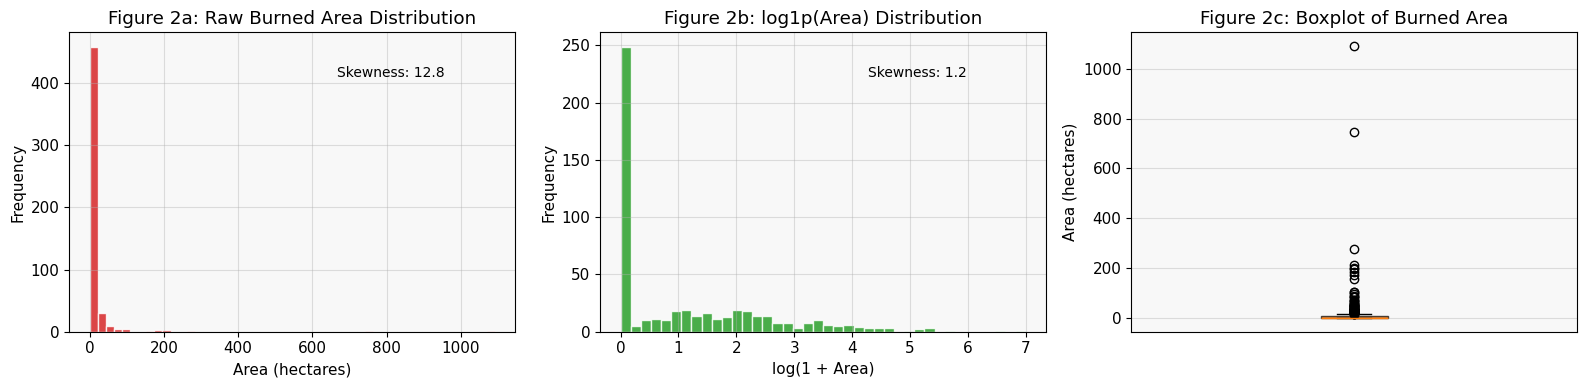

Fires with 0 ha burned: 247 / 517 (47.8%)
Max fire size: 1090.84 ha
Median fire size: 0.52 ha


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Raw area distribution
axes[0].hist(df_raw['area'], bins=50, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 2a: Raw Burned Area Distribution')
axes[0].set_xlabel('Area (hectares)')
axes[0].set_ylabel('Frequency')
axes[0].annotate(f"Skewness: {df_raw['area'].skew():.1f}", xy=(0.6, 0.85),
                 xycoords='axes fraction', fontsize=10, color='black')

# Plot 2: Log-transformed distribution
axes[1].hist(df['area_log'], bins=40, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].set_title('Figure 2b: log1p(Area) Distribution')
axes[1].set_xlabel('log(1 + Area)')
axes[1].set_ylabel('Frequency')
axes[1].annotate(f"Skewness: {df['area_log'].skew():.1f}", xy=(0.6, 0.85),
                 xycoords='axes fraction', fontsize=10, color='black')

# Plot 3: Boxplot of raw area
axes[2].boxplot(df_raw['area'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#ff7f0e', alpha=0.7))
axes[2].set_title('Figure 2c: Boxplot of Burned Area')
axes[2].set_ylabel('Area (hectares)')
axes[2].set_xticks([])

plt.tight_layout()
plt.savefig('outputs/fig2_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fires with 0 ha burned: {(df_raw['area']==0).sum()} / {len(df_raw)} ({(df_raw['area']==0).mean()*100:.1f}%)")
print(f"Max fire size: {df_raw['area'].max()} ha")
print(f"Median fire size: {df_raw['area'].median()} ha")

## 4. Feature Distributions

Histograms and boxplots for all numerical input features — helps us spot skewness, unusual ranges, and potential issues.

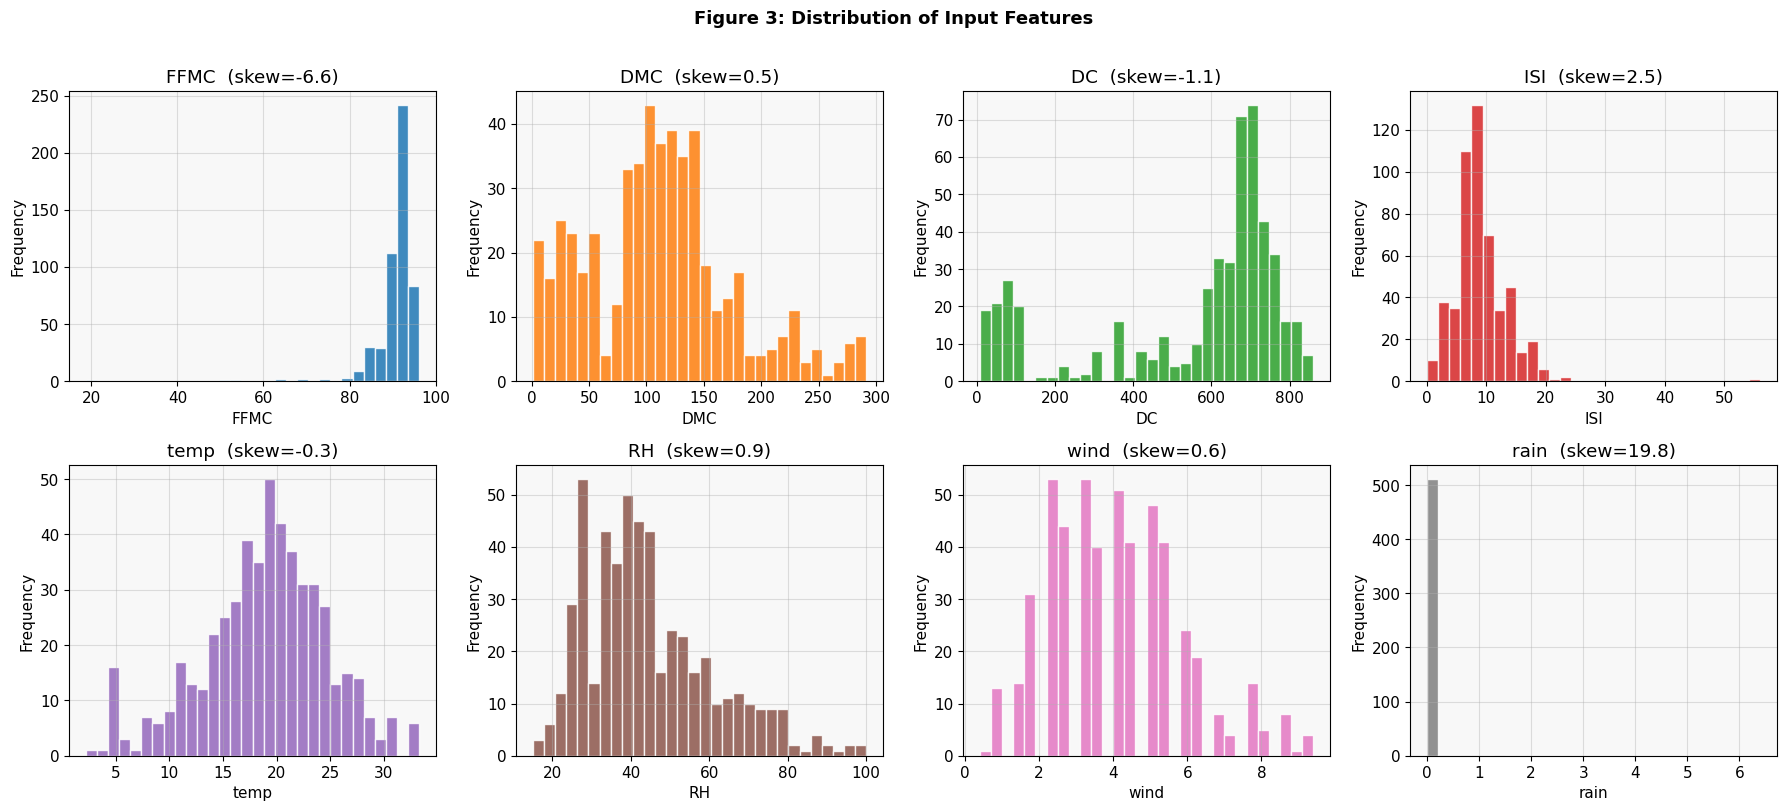

In [5]:
# Numerical features from the original dataset (before feature engineering)
original_features = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, col in enumerate(original_features):
    axes[i].hist(df_raw[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}  (skew={df_raw[col].skew():.1f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Figure 3: Distribution of Input Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

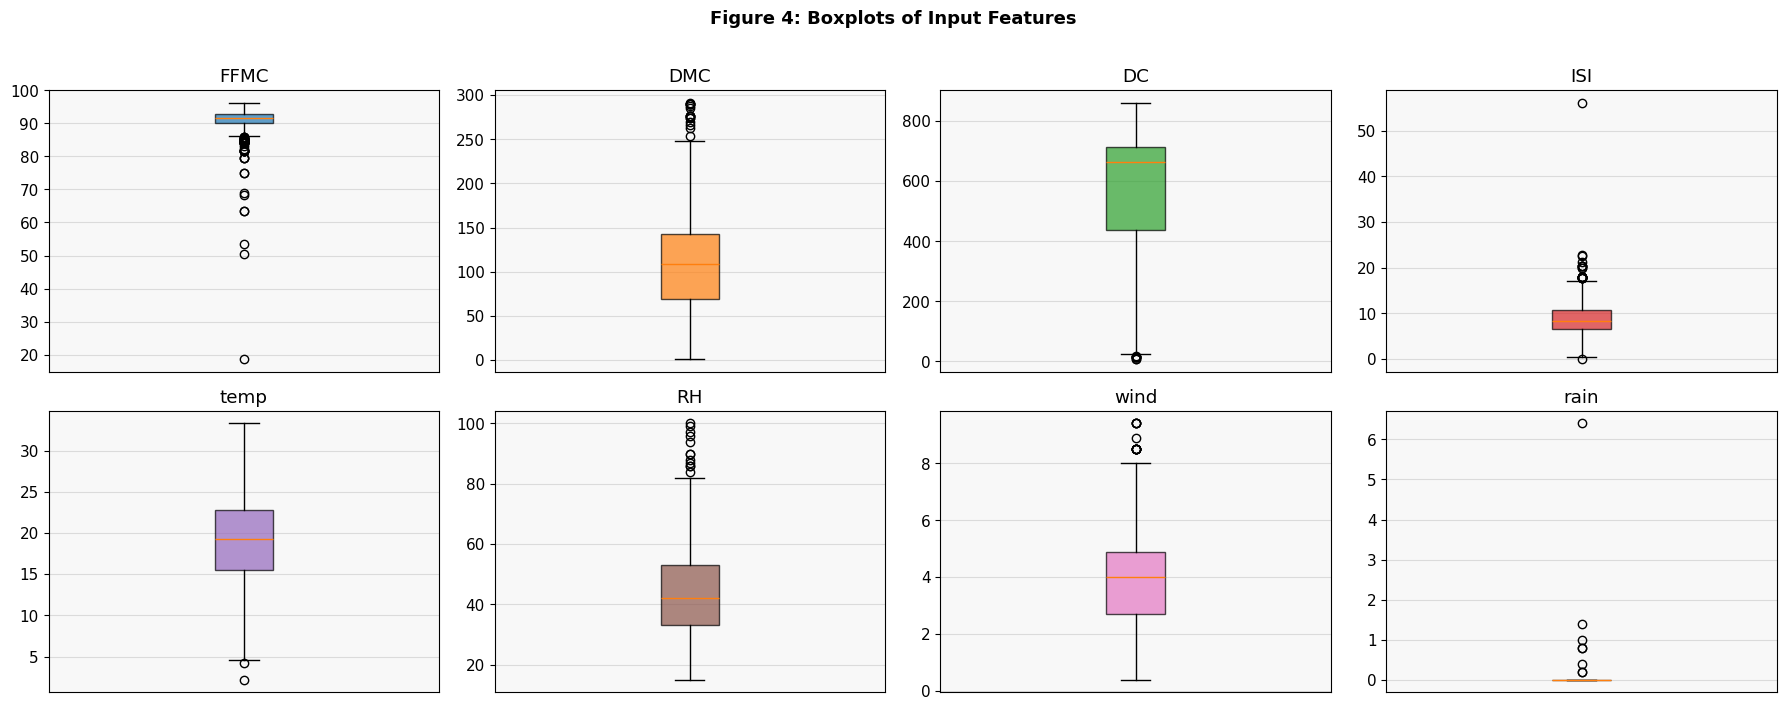

In [6]:
# Boxplots to visualise spread and outliers per feature
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(original_features):
    axes[i].boxplot(df_raw[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[i].set_title(col)
    axes[i].set_xticks([])

plt.suptitle('Figure 4: Boxplots of Input Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig4_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

A correlation matrix shows how strongly features are related to each other and to the target. Values close to +1 or -1 indicate strong relationships.

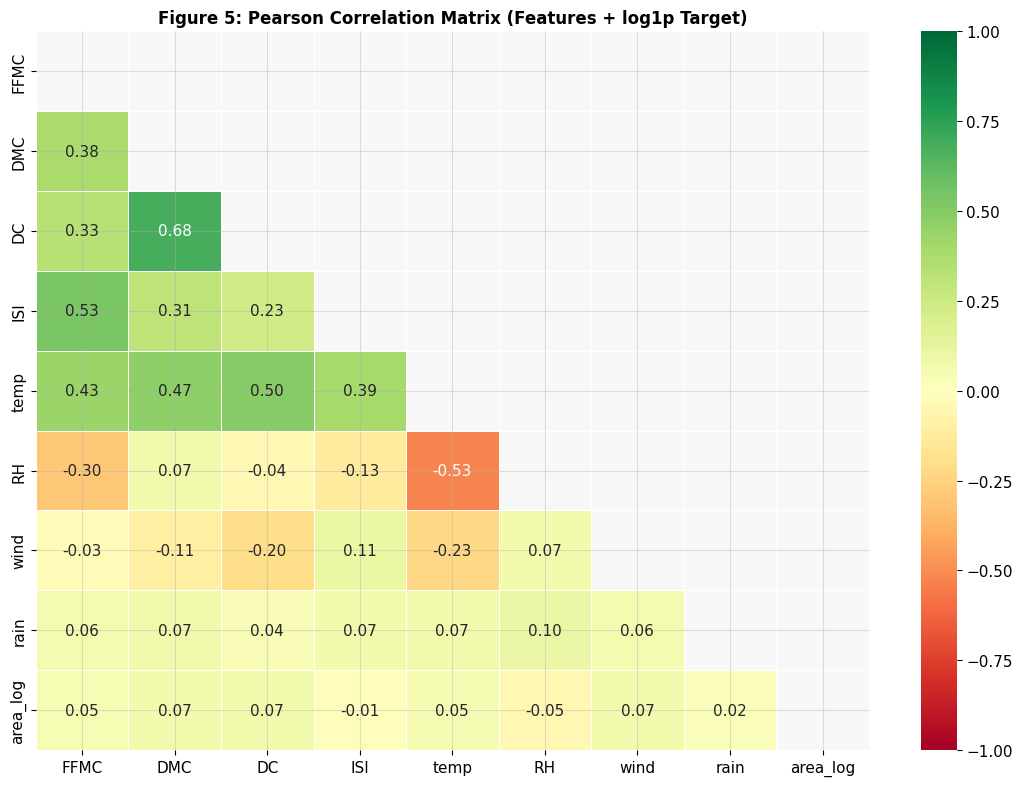

=== Correlation with log1p(area) ===
DMC     0.067
wind    0.067
DC      0.066
temp    0.053
FFMC    0.047
rain    0.023
ISI    -0.010
RH     -0.054
Name: area_log, dtype: float64


In [7]:
# Build a correlation dataframe including the log-transformed target
corr_df = df_raw[original_features].copy()
corr_df['area_log'] = df['area_log']

corr_matrix = corr_df.corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # only show lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Figure 5: Pearson Correlation Matrix (Features + log1p Target)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with the target specifically
print("=== Correlation with log1p(area) ===")
print(corr_matrix['area_log'].drop('area_log').sort_values(ascending=False).round(3))

## 6. Feature vs Target Relationships

Scatter plots of each feature against the log-transformed burned area. These help us visually identify which features have a linear or non-linear relationship with fire size.

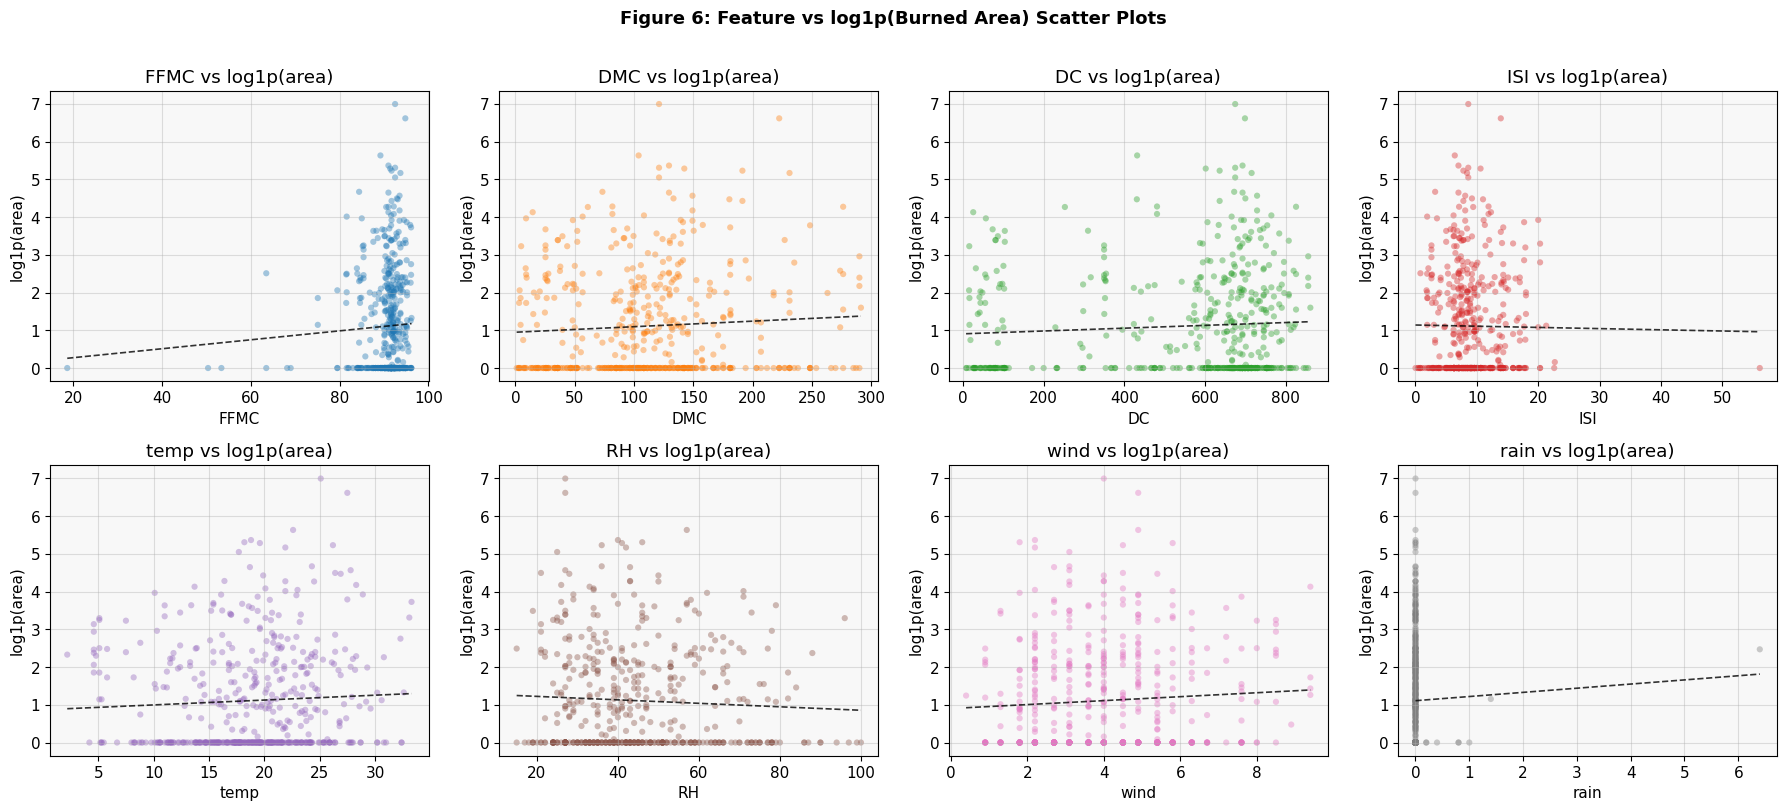

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(original_features):
    axes[i].scatter(df_raw[col], df['area_log'],
                    alpha=0.4, s=20, color=colors[i], edgecolors='none')
    # Add a trend line
    z = np.polyfit(df_raw[col], df['area_log'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_raw[col].min(), df_raw[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', linewidth=1.2, alpha=0.8, label='Trend')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log1p(area)')
    axes[i].set_title(f'{col} vs log1p(area)')

plt.suptitle('Figure 6: Feature vs log1p(Burned Area) Scatter Plots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig6_feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Temporal Analysis — Monthly and Daily Patterns

Are fires more common or larger in certain months or days? This matters for resource planning (e.g. deploying firefighters in high-risk months).

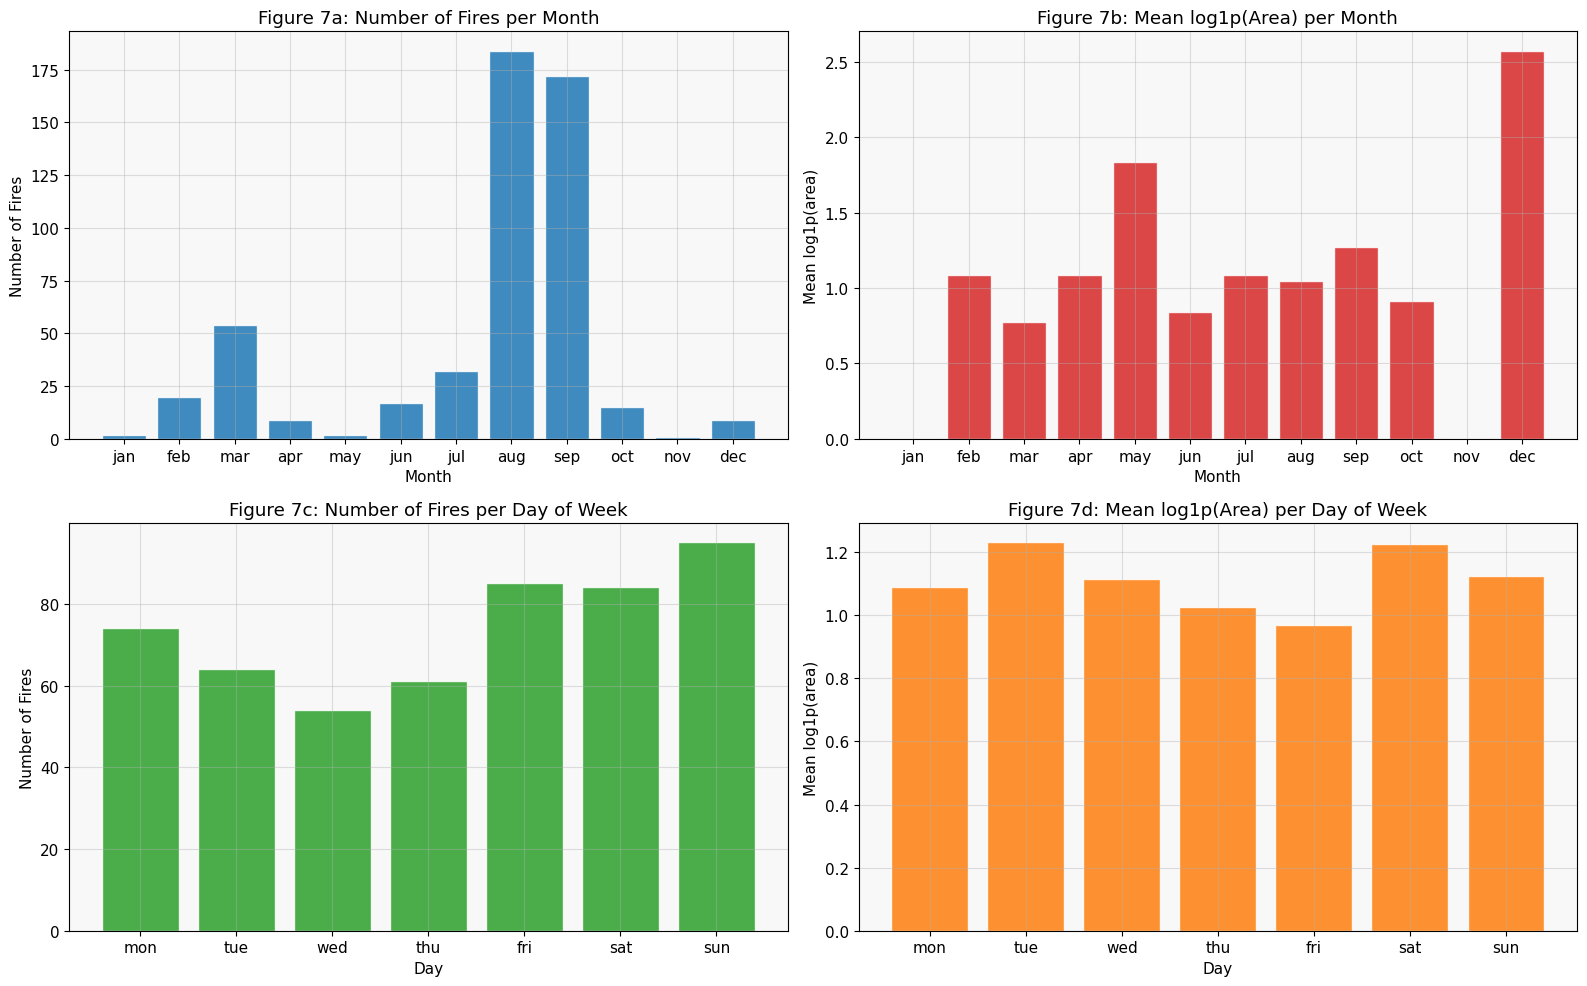

Top 3 months by fire count:
month
aug    184
sep    172
mar     54
Name: count, dtype: int64

Top 3 months by mean burned area:
month
dec    2.571670
may    1.837897
sep    1.274537
Name: area_log, dtype: float64


In [9]:
# Month ordering for proper chronological display
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order   = ['mon','tue','wed','thu','fri','sat','sun']

# Add log1p area to raw dataframe for these plots
df_raw['area_log'] = df['area_log']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Number of fires per month
month_counts = df_raw['month'].value_counts().reindex(month_order)
axes[0, 0].bar(month_order, month_counts, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Figure 7a: Number of Fires per Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Fires')

# Plot 2: Mean burned area per month
month_area = df_raw.groupby('month')['area_log'].mean().reindex(month_order)
axes[0, 1].bar(month_order, month_area, color='#d62728', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Figure 7b: Mean log1p(Area) per Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Mean log1p(area)')

# Plot 3: Number of fires per day
day_counts = df_raw['day'].value_counts().reindex(day_order)
axes[1, 0].bar(day_order, day_counts, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Figure 7c: Number of Fires per Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Fires')

# Plot 4: Mean burned area per day
day_area = df_raw.groupby('day')['area_log'].mean().reindex(day_order)
axes[1, 1].bar(day_order, day_area, color='#ff7f0e', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Figure 7d: Mean log1p(Area) per Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Mean log1p(area)')

plt.tight_layout()
plt.savefig('outputs/fig7_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 months by fire count:")
print(month_counts.sort_values(ascending=False).head(3))
print("\nTop 3 months by mean burned area:")
print(month_area.sort_values(ascending=False).head(3))

## 8. Spatial Analysis — Where Do Fires Occur?

X and Y are grid coordinates within Montesinho Natural Park. We can visualise which areas of the park experience the most fires and the largest fires.

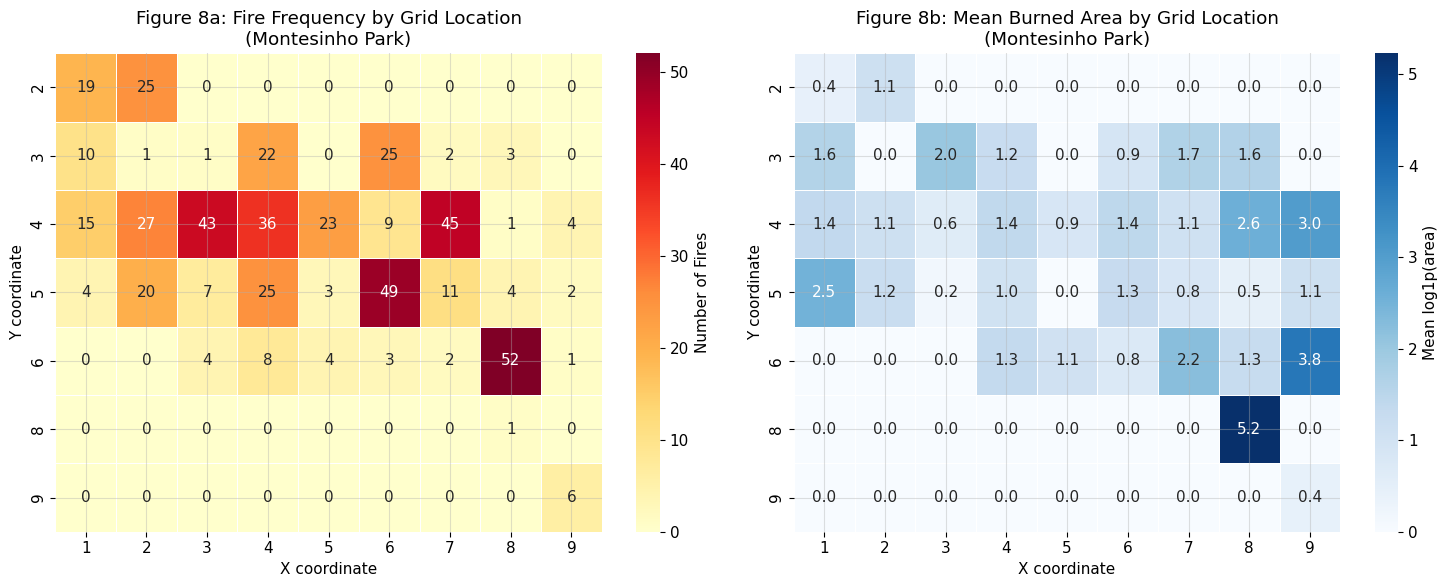

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Fire frequency heatmap by grid location
fire_counts_grid = df_raw.groupby(['X', 'Y']).size().reset_index(name='count')
pivot_count = fire_counts_grid.pivot(index='Y', columns='X', values='count').fillna(0)
sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Number of Fires'})
axes[0].set_title('Figure 8a: Fire Frequency by Grid Location\n(Montesinho Park)')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')

# Plot 2: Mean burned area heatmap by grid location
fire_area_grid = df_raw.groupby(['X', 'Y'])['area_log'].mean().reset_index()
pivot_area = fire_area_grid.pivot(index='Y', columns='X', values='area_log').fillna(0)
sns.heatmap(pivot_area, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Mean log1p(area)'})
axes[1].set_title('Figure 8b: Mean Burned Area by Grid Location\n(Montesinho Park)')
axes[1].set_xlabel('X coordinate')
axes[1].set_ylabel('Y coordinate')

plt.tight_layout()
plt.savefig('outputs/fig8_spatial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Engineered Features Analysis

We created 4 new features in Notebook 1. Let's check how they relate to the target and whether they add useful information.

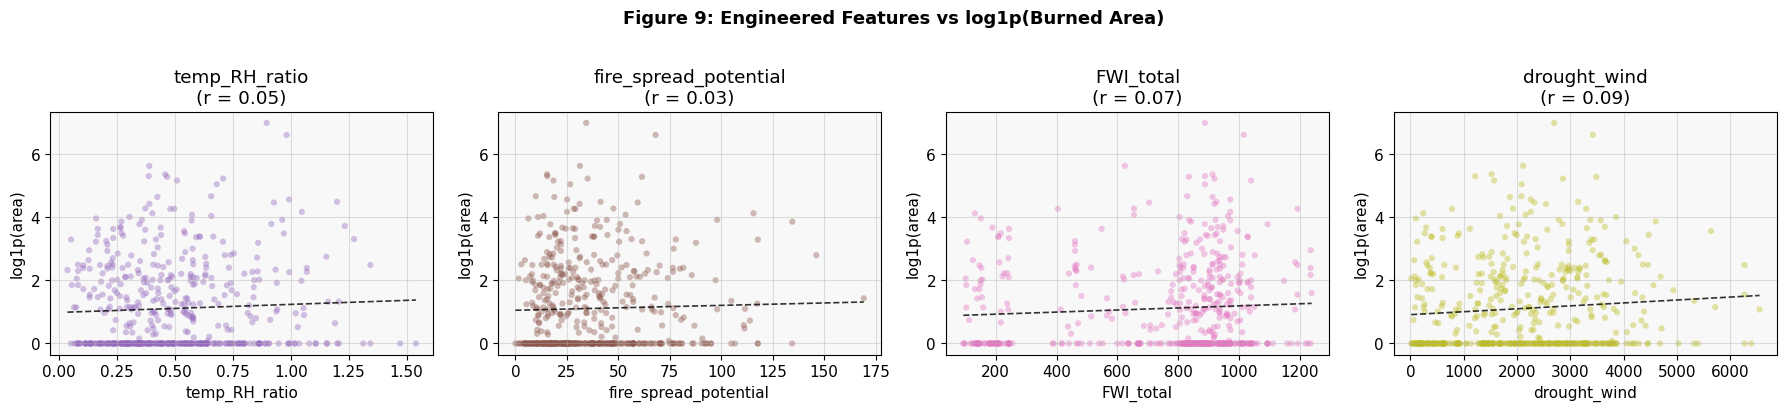

In [11]:
engineered_features = ['temp_RH_ratio', 'fire_spread_potential', 'FWI_total', 'drought_wind']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
eng_colors = ['#9467bd', '#8c564b', '#e377c2', '#bcbd22']

for i, col in enumerate(engineered_features):
    axes[i].scatter(df[col], df['area_log'],
                    alpha=0.4, s=20, color=eng_colors[i], edgecolors='none')
    # Trend line
    z = np.polyfit(df[col], df['area_log'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', linewidth=1.2, alpha=0.8)
    r = np.corrcoef(df[col], df['area_log'])[0, 1]
    axes[i].set_title(f'{col}\n(r = {r:.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log1p(area)')

plt.suptitle('Figure 9: Engineered Features vs log1p(Burned Area)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig9_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Pairplot — Key Features

A pairplot shows all pairwise relationships between selected features at once, coloured by fire severity (small vs large).

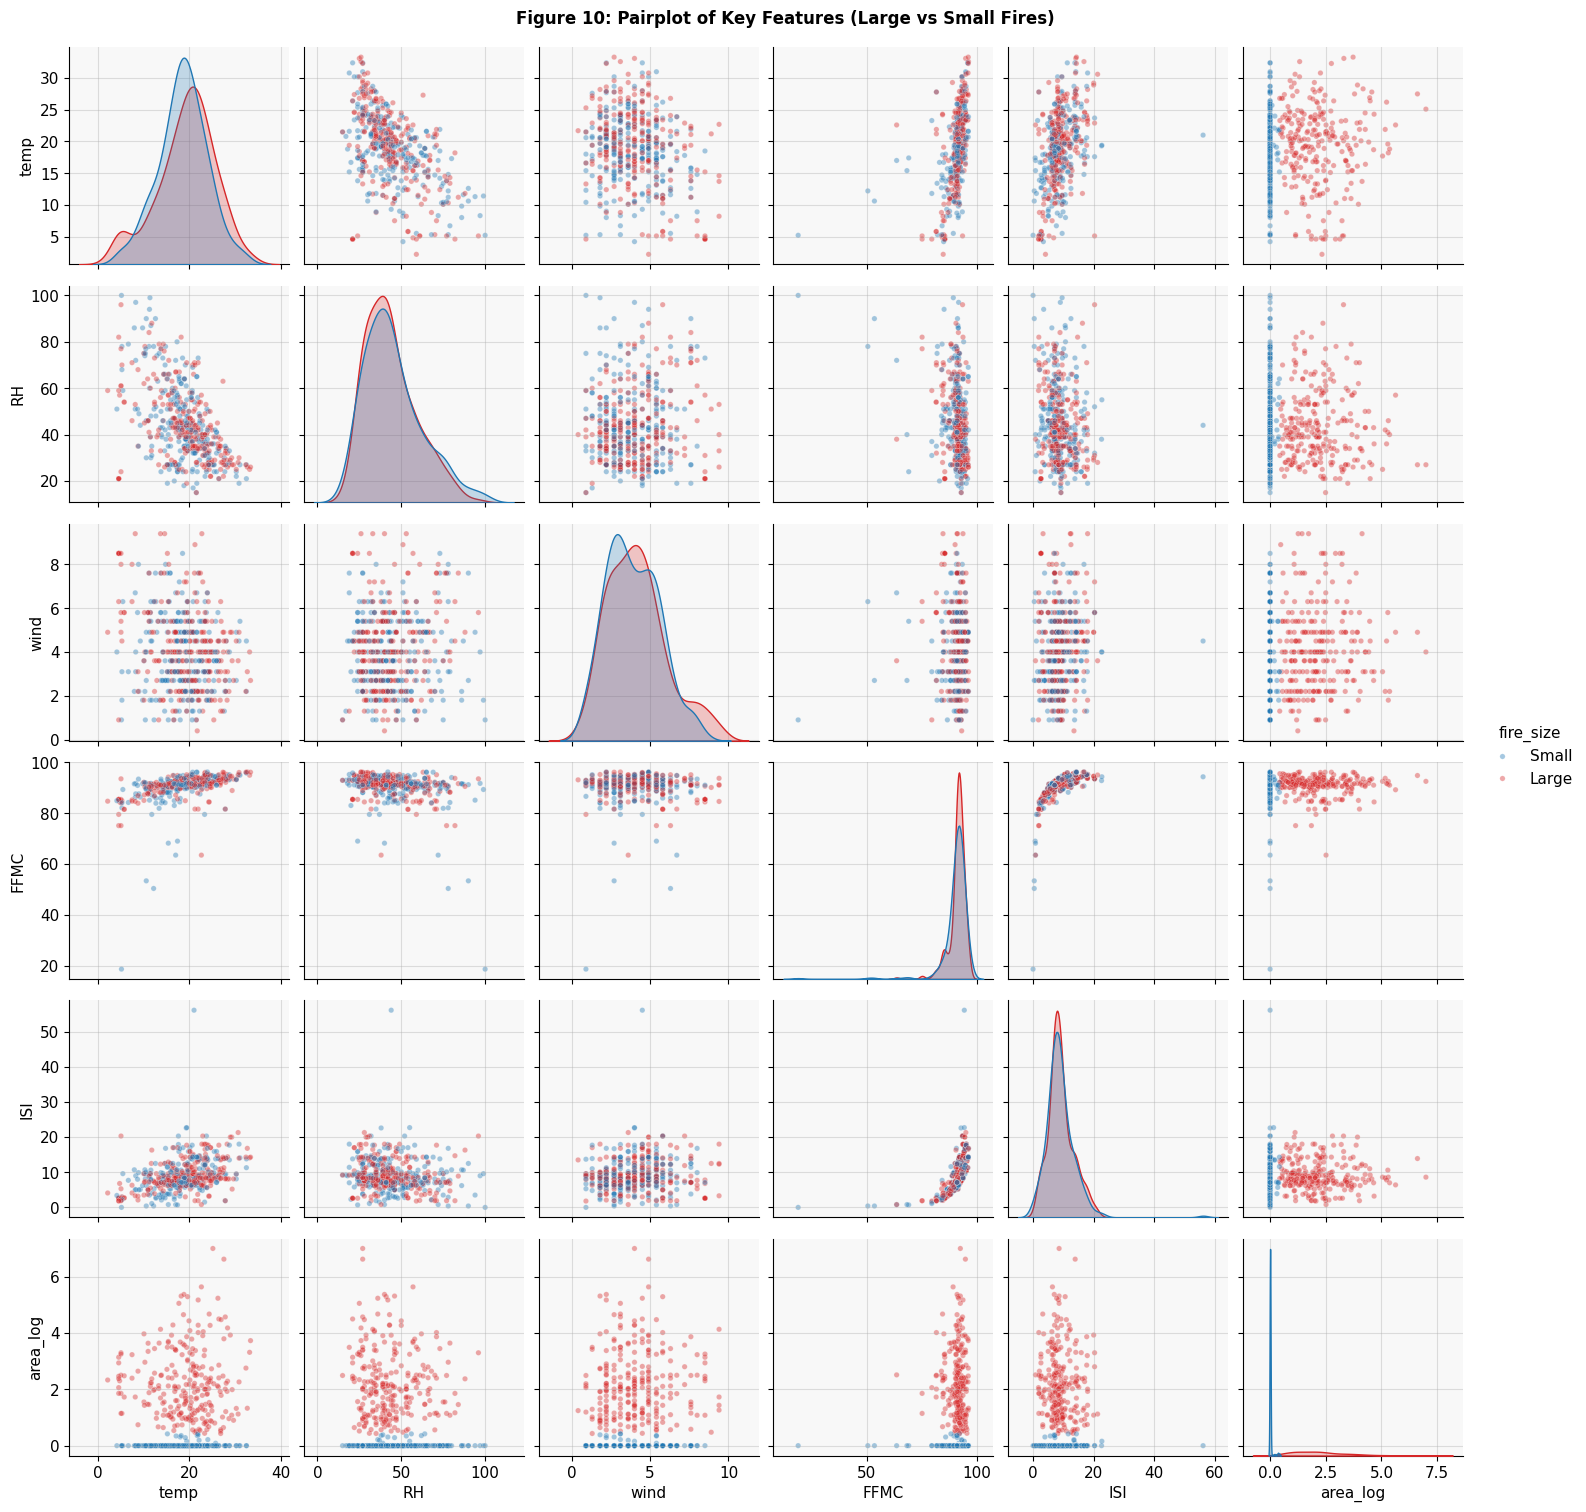

In [12]:
# Label fires as 'Large' (area > median) vs 'Small' (area <= median) for colour coding
median_area = df_raw['area_log'].median()
df_raw['fire_size'] = df_raw['area_log'].apply(lambda x: 'Large' if x > median_area else 'Small')

# Select the most informative features for the pairplot
pairplot_features = ['temp', 'RH', 'wind', 'FFMC', 'ISI', 'area_log']

pp = sns.pairplot(
    df_raw[pairplot_features + ['fire_size']],
    hue='fire_size',
    palette={'Large': '#d62728', 'Small': '#1f77b4'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
pp.fig.suptitle('Figure 10: Pairplot of Key Features (Large vs Small Fires)', y=1.01, fontsize=12, fontweight='bold')
pp.fig.savefig('outputs/fig10_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Key EDA Findings Summary

This section summarises the most important insights from the exploratory analysis.

In [13]:
# Print a structured summary of findings
print("="*60)
print("EDA KEY FINDINGS SUMMARY")
print("="*60)

print("\n[TARGET VARIABLE]")
print(f"  - 47.8% of fires have zero burned area (no spread recorded)")
print(f"  - Raw area is heavily right-skewed (skewness = {df_raw['area'].skew():.1f})")
print(f"  - log1p transformation reduces skewness to ~{df['area_log'].skew():.1f}")

print("\n[TEMPORAL PATTERNS]")
top_month = df_raw.groupby('month')['area_log'].mean().idxmax()
top_count_month = df_raw['month'].value_counts().idxmax()
print(f"  - Most fires occur in: {top_count_month.upper()} and AUG (summer peak)")
print(f"  - Largest fires on average in: {top_month.upper()}")
print(f"  - Weekend fires tend to be slightly larger (possibly leisure activities)")

print("\n[FEATURE CORRELATIONS WITH TARGET]")
corr_with_target = corr_matrix['area_log'].drop('area_log').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    print(f"  {feat:>12}: {val:+.3f}")

print("\n[SPATIAL PATTERNS]")
print("  - Fires are concentrated in the north-east of Montesinho Park")
print("  - Some grid zones consistently show higher burned areas")

print("\n[FEATURE ENGINEERING]")
for col in engineered_features:
    r = np.corrcoef(df[col], df['area_log'])[0, 1]
    print(f"  {col:>25}: r = {r:+.3f}")

print("\n[MODELLING IMPLICATIONS]")
print("  - Low linear correlations suggest non-linear models may outperform linear ones")
print("  - Feature engineering adds signal — keep all 4 engineered features")
print("  - Temporal and spatial features carry meaningful fire risk information")
print("="*60)

EDA KEY FINDINGS SUMMARY

[TARGET VARIABLE]
  - 47.8% of fires have zero burned area (no spread recorded)
  - Raw area is heavily right-skewed (skewness = 12.8)
  - log1p transformation reduces skewness to ~1.2

[TEMPORAL PATTERNS]
  - Most fires occur in: AUG and AUG (summer peak)
  - Largest fires on average in: DEC
  - Weekend fires tend to be slightly larger (possibly leisure activities)

[FEATURE CORRELATIONS WITH TARGET]
           DMC: +0.067
          wind: +0.067
            DC: +0.066
          temp: +0.053
          FFMC: +0.047
          rain: +0.023
           ISI: -0.010
            RH: -0.054

[SPATIAL PATTERNS]
  - Fires are concentrated in the north-east of Montesinho Park
  - Some grid zones consistently show higher burned areas

[FEATURE ENGINEERING]
              temp_RH_ratio: r = +0.050
      fire_spread_potential: r = +0.029
                  FWI_total: r = +0.070
               drought_wind: r = +0.088

[MODELLING IMPLICATIONS]
  - Low linear correlations sugges

In [14]:
# Save the findings summary to a text file for the report
findings = {
    'total_records': len(df_raw),
    'zero_area_pct': round((df_raw['area']==0).mean()*100, 1),
    'raw_skewness': round(df_raw['area'].skew(), 2),
    'log_skewness': round(df['area_log'].skew(), 2),
    'top_fire_month': df_raw['month'].value_counts().idxmax(),
    'top_area_month': df_raw.groupby('month')['area_log'].mean().idxmax(),
    'feature_correlations': corr_matrix['area_log'].drop('area_log').round(3).to_dict()
}

import json
with open('outputs/eda_findings.json', 'w') as f:
    json.dump(findings, f, indent=2)

print("EDA findings saved to outputs/eda_findings.json")
print("\nAll figures saved to outputs/ folder:")
for f in sorted(os.listdir('outputs')):
    if f.startswith('fig'):
        print(f"  {f}")

print("\n→ Next step: Notebook 3 — AI Modelling")

EDA findings saved to outputs/eda_findings.json

All figures saved to outputs/ folder:
  fig10_pairplot.png
  fig12_training_curves.png
  fig13_model_comparison.png
  fig14_predicted_vs_actual.png
  fig1_area_distribution.png
  fig2_target_analysis.png
  fig3_feature_distributions.png
  fig4_feature_boxplots.png
  fig5_correlation_matrix.png
  fig6_feature_vs_target.png
  fig7_temporal_analysis.png
  fig8_spatial_analysis.png
  fig9_engineered_features.png

→ Next step: Notebook 3 — AI Modelling
